# Comparison of Nodal Prices: FBMC vs DCOPF with IP Pricing

This notebook compares nodal prices calculated using:
1. Flow-Based Market Coupling (FBMC)
2. DC Optimal Power Flow (DCOPF) with IP pricing

We'll analyze the differences between these approaches and their implications.

In [37]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from allocation.algorithms.nodal_clearing.nodal_fbmc import NodalDispatchModel
from allocation.algorithms.zonal_clearing.zonal_configuration import node_zone_mapper

In [38]:
# Load the network
network = pypsa.Network("./data/raw_data/pypsa_eur_small/elec_s_40_ec_lv1.5_.nc")

# Calculate PTDF matrix
network.determine_network_topology()
sub_network_objects = network.sub_networks.obj

if len(sub_network_objects) == 0:
    raise ValueError("No subnetworks found. The network might be empty or invalid.")
elif len(sub_network_objects) > 1:
    print(f"Warning: Found {len(sub_network_objects)} electrical subnetworks. "
          "PTDF will be calculated for the largest one.")
    main_sub_network = max(sub_network_objects, key=lambda sn: len(sn.buses()))
else:
    main_sub_network = sub_network_objects[0]
    
print(f"Selected the main subnetwork with {len(main_sub_network.buses())} buses.")
main_sub_network.calculate_PTDF()

ptdf_numpy = main_sub_network.PTDF
lines = main_sub_network.lines_i()
buses = main_sub_network.buses_i()
print(f"PTDF matrix shape: {ptdf_numpy.shape} (lines: {len(lines)}, buses: {len(buses)})")

ptdf = pd.DataFrame(ptdf_numpy, index=lines, columns=buses)
nodal_ptdf = pd.DataFrame(0.0, index=network.lines.index, columns=network.buses.index)
nodal_ptdf.loc[lines, buses] = ptdf

Selected the main subnetwork with 40 buses.
PTDF matrix shape: (68, 40) (lines: 68, buses: 40)


In [39]:
# --- DATA CLEANING AND CONSISTENCY CHECK ---
# Check and fix missing generator time series data

static_gens = network.generators.index
timeseries_gens = network.generators_t.p_max_pu.columns
missing_gens = static_gens.difference(timeseries_gens)

if not missing_gens.empty:
    print(f"Found {len(missing_gens)} generators missing from the time-series 'p_max_pu' DataFrame.")
    print("These are likely conventional generators. Adding them with 100% availability.")
    
    # For each missing generator, create a new time-series with constant value of 1.0
    for gen_name in missing_gens:
        availability_profile = pd.Series(1.0, index=network.snapshots, name=gen_name)
        network.generators_t.p_max_pu[gen_name] = availability_profile
        
    print("\nData cleaning complete. 'network.generators_t.p_max_pu' is now consistent.")
    
    # Re-check the difference
    final_missing = network.generators.index.difference(network.generators_t.p_max_pu.columns)
    if final_missing.empty:
        print("Verification successful: All generators are now present in the time-series data.")
    else:
        print("!!! Verification FAILED. There is still a mismatch. !!!")
else:
    print("Data consistency check passed. No missing generators in 'p_max_pu'.")

Found 320 generators missing from the time-series 'p_max_pu' DataFrame.
These are likely conventional generators. Adding them with 100% availability.

Data cleaning complete. 'network.generators_t.p_max_pu' is now consistent.
Verification successful: All generators are now present in the time-series data.


C:\Users\paulw\AppData\Local\Temp\ipykernel_26024\923410533.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  network.generators_t.p_max_pu[gen_name] = availability_profile
C:\Users\paulw\AppData\Local\Temp\ipykernel_26024\923410533.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  network.generators_t.p_max_pu[gen_name] = availability_profile
C:\Users\paulw\AppData\Local\Temp\ipykernel_26024\923410533.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many time

In [41]:
# Calculate FBMC nodal prices
nodal_model = NodalDispatchModel()
nodal_results = nodal_model.solve(network, nodal_ptdf, verbose=False)

# Extract the DataFrame of nodal prices from the results
new_model_prices_wide = nodal_results['duals']['nodal_price']

# Reset the index to turn the 'period' from an index into a column
new_model_prices_long = new_model_prices_wide.reset_index()

# Use pd.melt to transform the DataFrame from wide to long format
new_model_prices = pd.melt(
    new_model_prices_long,
    id_vars=['index'],
    var_name='node',
    value_name='price_new_model'
)

# Rename the 'index' column to 'period' for clarity
new_model_prices.rename(columns={'index': 'period'}, inplace=True)

# Gurobi provides duals for the power balance constraints, which are costs.
# We'll assume they are the prices. If they need scaling, you would do it here.

print("Prices from the new model (long format):")
new_model_prices.head()


Set parameter LogToConsole to value 0
Optimal MILP solution found. Total Cost: 18073552.70
Prices from the new model (long format):


,period,node,price_new_model
0,2013-03-01 00:00:00,DE0 0,-14.904368
1,2013-03-01 01:00:00,DE0 0,-14.903841
2,2013-03-01 02:00:00,DE0 0,-14.904062
3,2013-03-01 03:00:00,DE0 0,-14.904584
4,2013-03-01 04:00:00,DE0 0,-28.189080


In [ ]:

# Load the existing prices from the CSV file
path = 'C:/projekte/HiWi/APEM/results/PyPSA_Eur_Small_results/DCOPF/IP_results/IP_prices.csv'

existing_prices = pd.read_csv(path)


# Create a mapping from the integer period to the timestamp period
# This assumes the integer periods in the CSV correspond to the order of snapshots.
period_mapping = {i+1: p for i, p in enumerate(new_model_prices['period'].unique())}
existing_prices['period_timestamp'] = existing_prices['period'].map(period_mapping)

# Rename the original price column to avoid confusion after merging
existing_prices.rename(columns={'price': 'price_existing_model'}, inplace=True)


print("Prices from the existing model (with mapped timestamp):")
existing_prices.head()


Prices from the existing model (with mapped timestamp):


,node,period,price_existing_model,period_timestamp
0,DE0 0,1,28.21,2013-03-01 00:00:00
1,DE0 0,2,28.21,2013-03-01 01:00:00
2,DE0 0,3,28.21,2013-03-01 02:00:00
3,DE0 0,4,28.21,2013-03-01 03:00:00
4,DE0 0,5,34.12,2013-03-01 04:00:00


In [47]:
comparison_df = pd.merge(
    new_model_prices,
    existing_prices[['node', 'period_timestamp', 'price_existing_model']],
    left_on=['node', 'period'],
    right_on=['node', 'period_timestamp'],
    how='left'
)

# Drop the extra timestamp column from the merge
comparison_df.drop(columns=['period_timestamp'], inplace=True)

comparison_df['price_new_model']= comparison_df['price_new_model']*-1

# Calculate the difference in prices
comparison_df['price_difference'] = comparison_df['price_new_model'] - comparison_df['price_existing_model']

print("Merged DataFrame for Comparison:")


comparison_df.head(10)

Merged DataFrame for Comparison:


,period,node,price_new_model,price_existing_model,price_difference
0,2013-03-01 00:00:00,DE0 0,14.904368,28.21,-13.305632
1,2013-03-01 01:00:00,DE0 0,14.903841,28.21,-13.306159
2,2013-03-01 02:00:00,DE0 0,14.904062,28.21,-13.305938
3,2013-03-01 03:00:00,DE0 0,14.904584,28.21,-13.305416
4,2013-03-01 04:00:00,DE0 0,28.189080,34.12,-5.930920
5,2013-03-01 05:00:00,DE0 0,28.206766,51.23,-23.023234
6,2013-03-01 06:00:00,DE0 0,28.207789,49.31,-21.102211
7,2013-03-01 07:00:00,DE0 0,28.207789,49.31,-21.102211
8,2013-03-01 08:00:00,DE0 0,28.207789,49.31,-21.102211
9,2013-03-01 09:00:00,DE0 0,28.207789,49.31,-21.102211


In [48]:
# Calculate summary statistics for the price difference
price_diff_stats = comparison_df['price_difference'].describe()

print("Summary Statistics of the Price Difference (New - Existing):")
print(price_diff_stats)

# Calculate the Mean Absolute Error (MAE)
mae = comparison_df['price_difference'].abs().mean()
print(f"\nMean Absolute Error (MAE): {mae:.2f}")

Summary Statistics of the Price Difference (New - Existing):
count    960.000000
mean      -3.239787
std        9.645441
min      -44.802740
25%       -7.343184
50%       -0.003103
75%        1.101934
max       16.729080
Name: price_difference, dtype: float64

Mean Absolute Error (MAE): 6.20


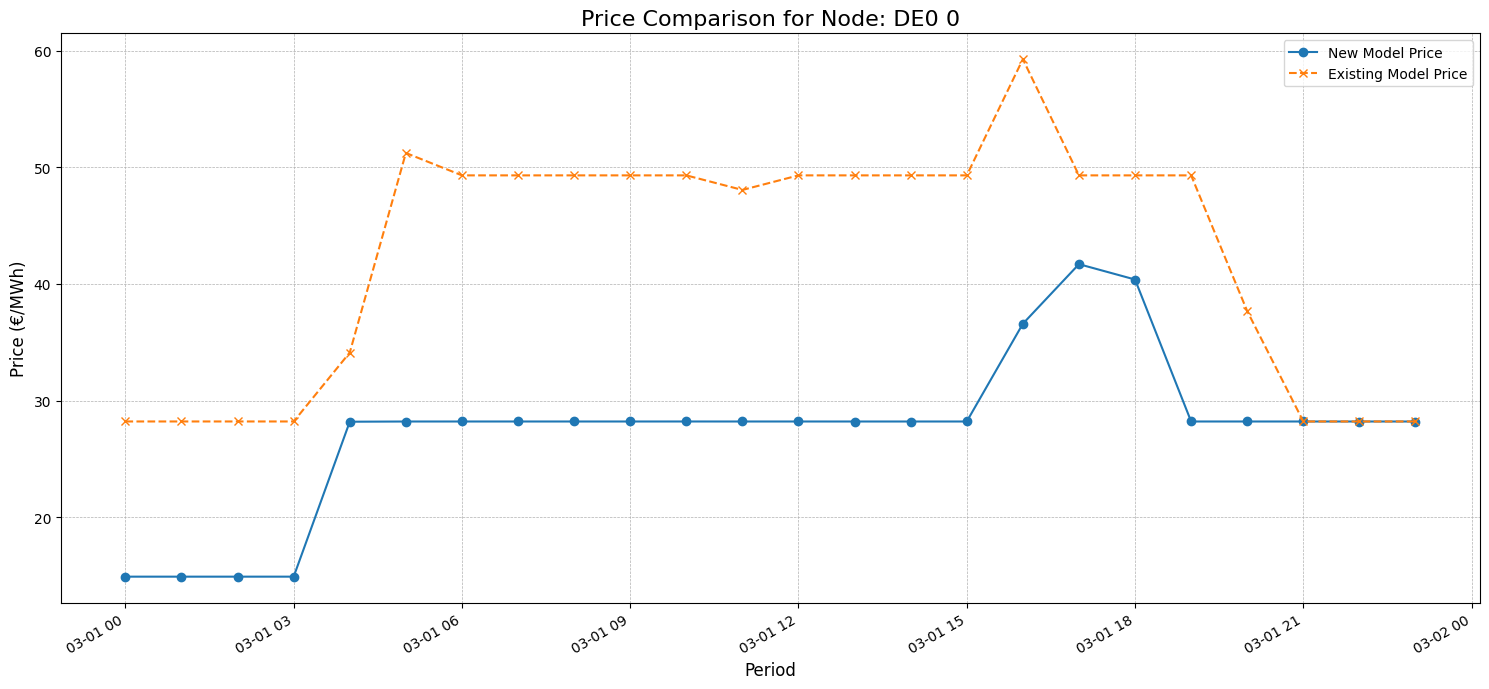

In [49]:
# Create the plot
fig, ax = plt.subplots(figsize=(15, 7))

# Choose a node to visualize
node_to_plot = 'DE0 0'
plot_data = comparison_df[comparison_df['node'] == node_to_plot]

# Plot the prices from both models
ax.plot(plot_data['period'], plot_data['price_new_model'], label='New Model Price', marker='o', linestyle='-')
ax.plot(plot_data['period'], plot_data['price_existing_model'], label='Existing Model Price', marker='x', linestyle='--')

# Formatting the plot
ax.set_title(f'Price Comparison for Node: {node_to_plot}', fontsize=16)
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Price (€/MWh)', fontsize=12)
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
fig.autofmt_xdate() # Rotates and aligns the x-axis labels (dates)
plt.tight_layout()
plt.show()

C:\Users\paulw\AppData\Local\Temp\ipykernel_26024\1549875651.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_for_boxplot, labels=nodes_unique)


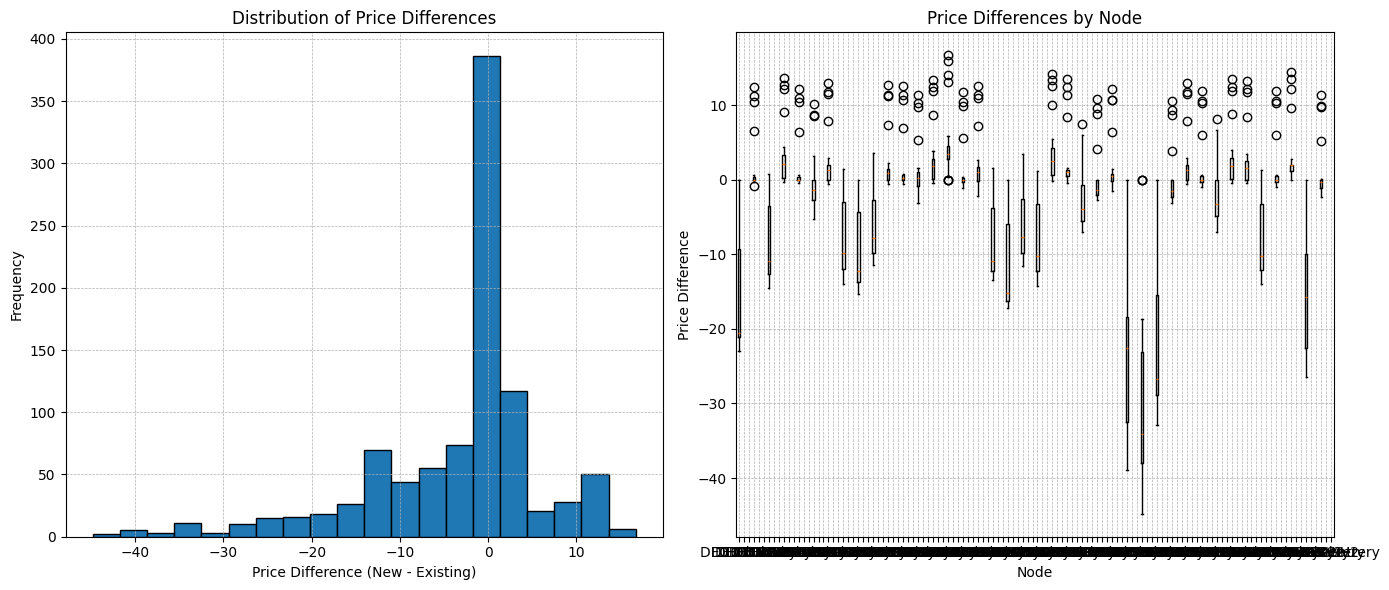

In [50]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: Histogram of the price differences ---
ax1.hist(comparison_df['price_difference'].dropna(), bins=20, edgecolor='black')
ax1.set_title('Distribution of Price Differences')
ax1.set_xlabel('Price Difference (New - Existing)')
ax1.set_ylabel('Frequency')
ax1.grid(True, linestyle='--', linewidth=0.5)

# --- Subplot 2: Boxplot of differences per node ---
# We need to prepare the data for matplotlib's boxplot, which expects a list of arrays
nodes_unique = sorted(comparison_df['node'].unique())
data_for_boxplot = [
    comparison_df[comparison_df['node'] == node]['price_difference'].dropna()
    for node in nodes_unique
]
ax2.boxplot(data_for_boxplot, labels=nodes_unique)
ax2.set_title('Price Differences by Node')
ax2.set_xlabel('Node')
ax2.set_ylabel('Price Difference')
ax2.grid(True, linestyle='--', linewidth=0.5)

# Show the combined plot
plt.tight_layout()
plt.show()